<a href="https://colab.research.google.com/github/smsag99/Thesis/blob/main/codes/dataExploring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Animal Data


Load the dataset from '/content/drive/MyDrive/Thesis_Data/Dati_ok.txt' into a pandas DataFrame.
| Variables | Meaning | Note |
| :--- | :--- | :--- |
| Farm_code | Identifier of FARM | |
| Animal_ID | Identifier Animal | |
| DTB | Date of birth of the animal | |
| DTC | Date of calving which provided the lactation | |
| DTT | Date of the test-date/milk quality control | |
| Parity | Parity order | |
| Milk_kg | Quantitiy of milk produced per day in kg during the test | Divide it by 10 |
| Fat_p | Percentage of Fat in the milk during the test-day | Divide it by 100 |
| Protein_p | Percentage of protein in the milk during the test-day | Divide it by 100 |
| cells | N. of cells per ml during the test-day | You will see the N. divided by 100000 |
| NM | N. of milking event per day | Usually 2 per day |

In [ ]:
datasetAnimalPath = '/content/drive/MyDrive/Thesis_Data/Dati_ok.txt'

In [ ]:
import pandas as pd

col_names = [
    'Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt',
    'parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM'
]

cleaned_rows = []

with open(datasetAnimalPath, 'r') as file:
    next(file)

    for line in file:
        line = line.strip()

        if not line:
            continue

        parts = line.split(',')

        if len(parts) == 11:
            cleaned_rows.append(parts)

        elif len(parts) == 12:
            parts.pop(2)
            cleaned_rows.append(parts)

df_animal = pd.DataFrame(cleaned_rows, columns=col_names)

numeric_cols = ['Farm_Code','parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']
for col in numeric_cols:
    df_animal[col] = pd.to_numeric(df_animal[col], errors='coerce')

date_cols = ['dtb', 'dtc', 'dtt']
for col in date_cols:
    df_animal[col] = pd.to_datetime(df_animal[col], format='%Y%m%d', errors='coerce')

print(df_animal.head(5))
print(f"\nTotal rows loaded: {len(df_animal)}")

   Farm_Code       Animal_ID        dtb        dtc        dtt  parity  \
0     521513  IT003990094624 2013-10-29 2022-06-07 2022-06-20       6   
1     521513  IT003990094624 2013-10-29 2022-06-07 2022-07-19       6   
2     521513  IT003990094624 2013-10-29 2022-06-07 2022-09-12       6   
3     521513  IT003990094624 2013-10-29 2022-06-07 2022-10-13       6   
4     521513  IT003990094624 2013-10-29 2022-06-07 2022-11-15       6   

   milk_kg  fat_p  protein_p  cells  NM  
0      141    617        484    656   2  
1      168    682        417    827   2  
2      134    763        459   1144   2  
3      108    663        454   1403   2  
4       94    688        451   1805   2  

Total rows loaded: 2593267


In [ ]:
df_animal.isnull().sum()

,0
Farm_Code,0
Animal_ID,0
dtb,1873
dtc,0
dtt,0
parity,0
milk_kg,0
fat_p,0
protein_p,0
cells,0


In [ ]:
import pandas as pd

print("Descriptive statistics for numerical columns:")

pd.options.display.float_format = '{:.0f}'.format

df_animal.describe()[['parity','milk_kg','fat_p','protein_p','cells','NM']].loc[['mean','std', 'min' ,'max']]

# pd.options.display.float_format = None

Descriptive statistics for numerical columns:


,parity,milk_kg,fat_p,protein_p,cells,NM
mean,3,90,779,457,281,2
std,2,38,239,94,798,0
min,1,0,-387,-237,0,1
max,27,886,7943,8557,98147,3


### Visualizing Descriptive Statistics with Box Plots

Box plots are useful for visualizing the distribution of numerical data. They show the median, interquartile range (IQR), and potential outliers.

### Parameters Analysis

Generating data visualizations for numerical columns...


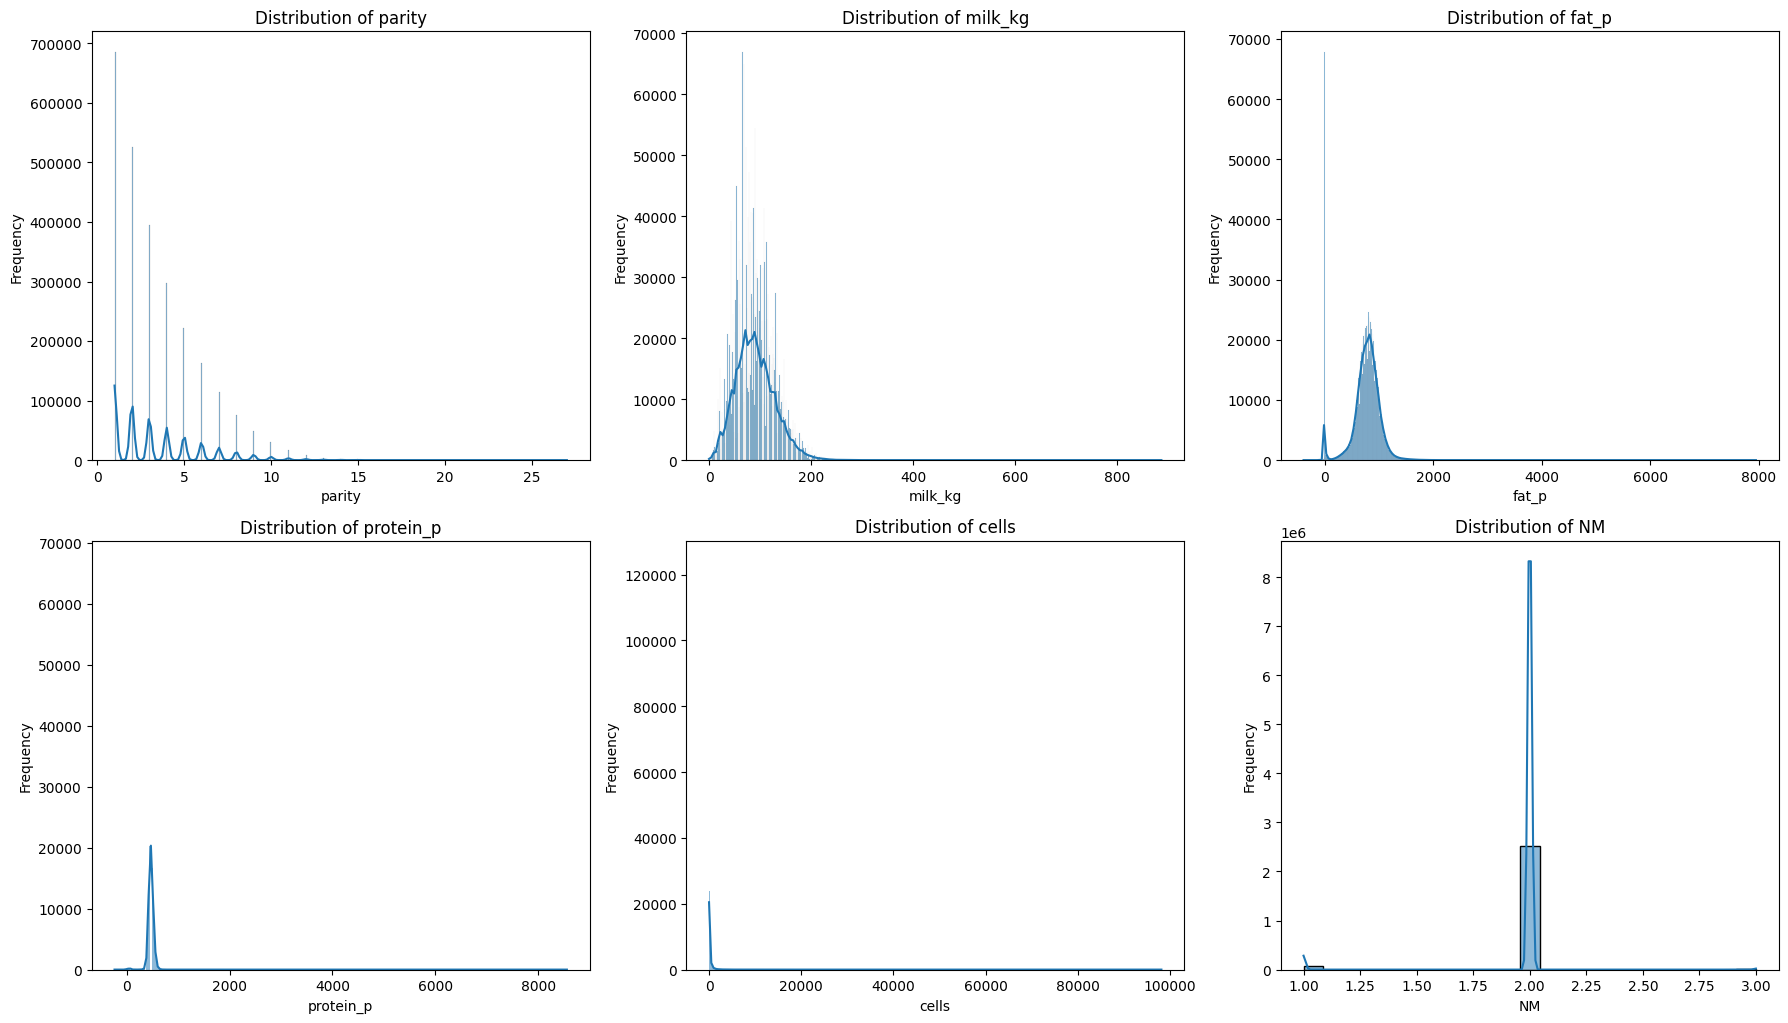

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating data visualizations for numerical columns...")

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten() # Flatten the 3x3 array of axes for easy iteration

numerical_cols = ['parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.histplot(df_animal[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### parity

In [ ]:
df_animal['parity'].quantile([0.01,0.99])

,parity
0.01,1.0
0.99,11.0


In [ ]:
len(df_animal[(df_animal['parity'] > 11) | (df_animal['parity'] < 1)])

17819

#### milk_kg

In [ ]:
df_animal['milk_kg'].quantile([0.01,0.99])

,milk_kg
0.01,18.0
0.99,193.0


In [ ]:
len(df_animal[(df_animal['milk_kg'] > 193) | (df_animal['milk_kg'] < 18)])

48143

#### fat_p


In [ ]:
len(df_animal[df_animal['fat_p']==0])

67455

In [ ]:
df_animal['fat_p'].quantile([0.03,0.99])

,fat_p
0.03,36.0
0.99,1327.0


In [ ]:
len(df_animal[(df_animal['fat_p'] > 1327) | (df_animal['fat_p'] < 36)])

103640

#### protein_p

In [ ]:
len(df_animal[df_animal['protein_p']==0])

66973

In [ ]:
df_animal['protein_p'].quantile([0.03,0.99])

,protein_p
0.03,63.0
0.99,588.0


In [ ]:
len(df_animal[(df_animal['protein_p'] > 588) | (df_animal['protein_p'] < 63)])

103271

#### cells

In [ ]:
len(df_animal[df_animal['cells']==0])

118300

In [ ]:
df_animal['cells'].quantile([0.05,0.99])

,cells
0.05,4.0
0.99,3081.0


In [ ]:
len(df_animal[(df_animal['cells'] > 3081) | (df_animal['cells'] < 4)])

152612

#### NM

In [ ]:
df_animal['NM'].value_counts()

,count
NM,
2,2515006
1,73012
3,5249


## Load Farm Data
Load the dataset from '/content/drive/MyDrive/Thesis_Data/latitude_and_longitude.xlsx' into a pandas DataFrame.
| Variables | Meaning | Example Value |
| :--- | :--- | :--- |
| Farm name | Primary name of the farm | ABBATE MARIA |
| Commercial name | Registered business or commercial name | ABBATE MARIA ANTONIET |
| Farm_code | Unique numerical identifier for the farm | 6811505 |
| ASL_code | Local Health Authority (Azienda Sanitaria Locale) code | 084CE077 |
| Adress | Physical street address of the farm | VIA NAZIONALE |
| City | City where the farm is located | SANTA MARIA CAPUA VETER |
| Postal_code | ZIP or Postal code | 81050 |
| Provinc | Province abbreviation (e.g., CE for Caserta) | CE |
| Region | Italian region (e.g., Campania, Toscana) | Campania |
| Latitude | Geographic latitude coordinate | 41.08175 |
| Longitude | Geographic longitude coordinate | 14.26614 |

In [ ]:
datasetFarmPath = '/content/drive/MyDrive/Thesis_Data/latitude and longitude.xlsx'

In [ ]:
import pandas as pd

col_names = [
    'Farm_name','Commercial_name','Farm_code','ASL_code','Adress','City','Postal_code','Province','Region','Latitude','Longitude'
]

df_farm = pd.read_excel(datasetFarmPath)

print(df_farm.head())
print(f"\nTotal rows loaded: {len(df_farm)}")

                 Farm name                       Commercial name  Farm_code  \
0  ABBATE MARIA ANTONIETTA               ABBATE MARIA ANTONIETTA    6811505   
1          BOTTAI LEONARDO  AGRIAMBIENTE MUGELLO SOC. COOP. AGR.    4241329   
2          DIANA VALENTINA              AGRICOLA DIANA VALENTINA    6811588   
3         GIULIANI ALVIDIO             AGRICOLA GIULIANI ALVIDIO    5600136   
4              RUBINO VITO    AGRICOLA LA PESCARA DI VITO RUBINO    6812804   

   ASL_code                                 Adress                      City  \
0  084CE077                          VIA NAZIONALE  SANTA MARIA CAPUA VETERE   
1  004FI004                   VIA DI GALLIANO 15/A      BARBERINO DI MUGELLO   
2  027CE147                     P.CO SAN BENEDETTO           CASTEL VOLTURNO   
3  005FR138                    VIA COLLE COTTO. 37                   AMASENO   
4  068CE017  Via Santa Lucia 3 Loc. Pietre Bianche                    RIARDO   

   Postal_code Province    Region  Latitude 

In [ ]:
df_farm.loc[164,'Province'] = 'CA'

### Farms on the Map

In [ ]:
import folium

# Calculate the mean latitude and longitude to center the map
mean_lat = df_farm['Latitude'].mean()
mean_lon = df_farm['Longitude'].mean()

# Create a base map centered around the mean coordinates
m = folium.Map(location=[mean_lat, mean_lon], zoom_start=6)

# Add a marker for each farm
for index, row in df_farm.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"<b>Farm:</b> {row['Farm name']}<br><b>Code:</b> {row['Farm_code']}",
        tooltip=row['Farm name']
    ).add_to(m)

# Display the map
m